# EDA. Данные о транзакциях 

**Задача:** предсказать суммарные переводы 51 963 клиентов банка за 12 недель (118–129),  
используя историю за 118 недель (0–117).

**Сырые данные:** еженедельные записи с суммами транзакций по клиентам банка. Изначально данные содержат в себе информацию по большему охвату клиентов, но они отфильтровываются, чтобы научиться предсказывать суммы переводов только для необходимых инн. Также в какие-то дни записи по необходимым клиентам могут отсутствовать. Чтобы поддержать непрервность данных, а также сохранить размерность чанков при разбиении по инн и дате, в данные добавляются записи о "фейковых транзакциях" - нулевая сумма перевода для каждого инн в каждый день.

**Метрика:** средний по клиентам RMSLE:
$$\overline{RMSLE} = \frac{1}{N}\sum_{i=1}^N \sqrt{\frac{1}{T}\sum_{t=1}^T (\log(1+y_{it}) - \log(1+\hat{y}_{it}))^2}$$

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import warnings
import json
from pathlib import Path
import gc, time

In [3]:
print("Loading data...")

DATA_DIR = Path("data")
TX_FILES = sorted(DATA_DIR.glob("transactions_[1-5].parquet"))

trns_chunks = []
for f in TX_FILES:
    print(f"Reading {f.name} ...")
    chunk = pd.read_parquet(f)
    print(f"  -> {len(chunk):,} rows")
    trns_chunks.append(chunk)

trns_raw = pd.concat(trns_chunks, ignore_index=True)
del trns_chunks
gc.collect()


trns = trns_raw.copy()

Loading data...
Reading transactions_1.parquet ...
  -> 52,089,892 rows
Reading transactions_2.parquet ...
  -> 55,045,806 rows
Reading transactions_3.parquet ...
  -> 59,510,350 rows
Reading transactions_4.parquet ...
  -> 61,492,247 rows
Reading transactions_5.parquet ...
  -> 30,036,951 rows


##  Характеристика данных 

Данные предоставлены банком. Это "сырые" записи о переводах юридических лиц, собранные за последние два года в виде временного ряда. Частота записей - день. Данные хранят в себе информаю об около 51 тыс клиентов и их сумах переводов за день. Перевод - общая сумма за день в рублях, перечисленная на другой счет/инн. 

In [4]:
# клиенты сами себе не переводили 
trns[trns['doc_payee_inn'] == trns['doc_payer_inn']]['doc_payer_inn'].nunique()

0

In [22]:
# нулов нет
na_counts = trns.isna().sum()
na_counts

date                           0
doc_payer_inn                  0
doc_payee_inn                  0
trns_count                     0
trns_amount                    0
doc_payer_bank_name_encoded    0
doc_payee_bank_name_encoded    0
doc_payer_bank_name_flag       0
doc_payee_bank_name_flag       0
trns_class_encoded             0
dtype: int64

In [7]:
# зато не для всех инн есть записи каждый день
ts_inn = pd.read_parquet(
    DATA_DIR / "target_series_extended.parquet", columns=["inn_id"]
)
allowed = ts_inn["inn_id"].unique()

calendar = pd.read_csv(
    DATA_DIR / "calendar_extended.csv", parse_dates=["date"]
)

cal_117 = calendar.loc[calendar["week"] <= 117].copy()
cal_117["date"] = (
    pd.to_datetime(cal_117["date"]).dt.tz_localize(None).dt.normalize()
)
all_dates = np.sort(cal_117["date"].drop_duplicates().to_numpy())

trns_allowed = trns[trns["doc_payer_inn"].isin(allowed)].copy()

n_inn, n_days = len(allowed), len(all_dates)
expected_pairs = n_inn * n_days

print("Клиентов (inn_id в target):", f"{n_inn:,}")
print("Календарных дней (week <= 117):", f"{n_days:,}")
print("Ожидаемых пар (ИНН × день):", f"{expected_pairs:,}")

Клиентов (inn_id в target): 51,963
Календарных дней (week <= 117): 826
Ожидаемых пар (ИНН × день): 42,921,438


In [24]:
present_pairs = (
    trns_allowed[["doc_payer_inn", "date"]].drop_duplicates().shape[0]
)
missing_pairs = expected_pairs - present_pairs
coverage = 100.0 * present_pairs / expected_pairs

print("\nУникальных пар (doc_payer_inn, date) в сырых транзакциях:", f"{present_pairs:,}")
print("Отсутствующих пар относительно полной сетки:", f"{missing_pairs:,}")
print(f"Доля покрытых пар: {coverage:.4f}%")


Уникальных пар (doc_payer_inn, date) в сырых транзакциях: 23,611,670
Отсутствующих пар относительно полной сетки: 19,309,768
Доля покрытых пар: 55.0114%


In [6]:
# подвыборка: случайные ИНН × одна неделя (тяжёлый groupby.size по всему датасету не делаем)
rng = np.random.default_rng(42)
k = min(500, len(allowed))
sample_inn = rng.choice(allowed, size=k, replace=False)

trns_w = trns_allowed.merge(
    cal_117[["date", "week"]].drop_duplicates(),
    on="date",
    how="left",
)

WEEK_SAMPLE = 50

sub = trns_w[
    trns_w["doc_payer_inn"].isin(sample_inn) & (trns_w["week"] == WEEK_SAMPLE)
]
sizes = sub.groupby(["doc_payer_inn", "date"], sort=False).size()

print(
    f"\nПодвыборка (EDA): {k} случайных ИНН, неделя {WEEK_SAMPLE}. "
    "Число строк на пару (ИНН, день) в сырых данных:"
)
print(sizes.describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_string())

NameError: name 'allowed' is not defined

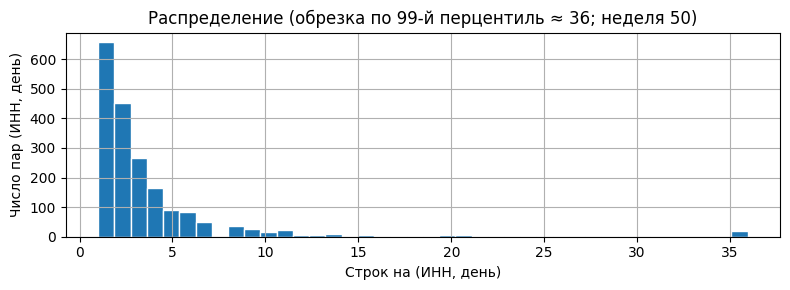

In [26]:
cap = float(sizes.quantile(0.99))
fig, ax = plt.subplots(figsize=(8, 3))
sizes.clip(upper=cap).hist(bins=40, ax=ax, edgecolor="white")
ax.set_xlabel("Строк на (ИНН, день)")
ax.set_ylabel("Число пар (ИНН, день)")
ax.set_title(
    f"Распределение (обрезка по 99-й перцентиль ≈ {cap:.0f}; неделя {WEEK_SAMPLE})"
)
plt.tight_layout()
plt.show()

На графике показано распределение "плотности "сырых данных - сколько записей по каждому инн есть в таблице по каждому дню. Так как исходный объем данных очень большой, для иллюстрации была выбрана неделя 50 и 500 рандомных юридических лиц. 

Из подсчетов выше видно, что в среднем на одного клиента приходится по 4 строки в датафрейме в день. Но встречаются и сильно повышенные значения - 35, 147.

График подтверждает сильную ассиметрию в данных. 


**Практические выводы:**
1. данные необходимо группировать понедельно для сглаживания ассиметрии 
2. разрывы в сетке (день, инн) необходимо восполнить 
3. логарифм-метрики хорошо подходят, так как меньше штрафуют за большие значения 

In [ ]:
# все клиенты, для которых делаем предсказание, осуществляли переводы не только со счетов втб
trns_allowed = trns[trns["doc_payer_inn"].isin(allowed)]
trns_allowed[trns_allowed['doc_payer_bank_name_flag'] == 0]['doc_payer_inn'].nunique()

51526

Такое наблюдение наталкивает на мысль о том, что собирать информацию о переводах в целом (а не только со счетов втб, как в постановке задачи) также полезно. 

## Обзор целевой переменной 

In [ ]:
#  см lightGBM_sarima(1).ipynb